=== STEP 1: Environment & Paths Setup ===
-> Execution Device: CPU

=== STEP 3: Model Initialization ===

=== STEP 2: Data Splitting (Dirichlet Non-IID) ===
Hospital 1 -> Total: 1992 | NORMAL: 274 | PNEUMONIA: 1718
   └─ Train: 1594 | Val: 398
Hospital 2 -> Total: 1330 | NORMAL: 560 | PNEUMONIA: 770
   └─ Train: 1064 | Val: 266
Hospital 3 -> Total: 1910 | NORMAL: 515 | PNEUMONIA: 1395
   └─ Train: 1528 | Val: 382

=== STEP 4: Local Training (FedRep) on Hospital 1 ===
Round 1 | Train Loss: 0.1365 | Val Loss: 0.1076 | Val Acc: 95.98% | Val AUC: 0.9971
Round 2 | Train Loss: 0.0787 | Val Loss: 0.0416 | Val Acc: 98.49% | Val AUC: 0.9985
Round 3 | Train Loss: 0.0500 | Val Loss: 0.0600 | Val Acc: 98.49% | Val AUC: 0.9987

=== STEP 5: Separate Test Set Evaluation ===
-> Test Set (624 images) Metrics:
   Accuracy: 92.95% | Macro F1: 0.9219 | AUC: 0.9822

=== STEP 6: Grad-CAM Explainability (2 Normal, 2 Pneumonia) ===


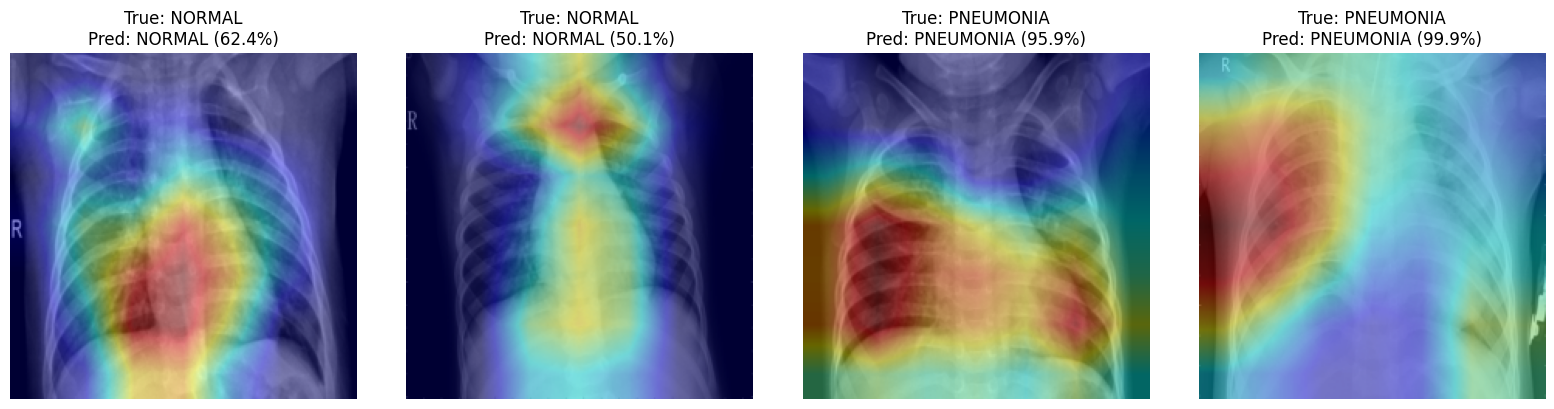


=== STEP 7: Saving Model Artifacts ===
-> Model saved successfully to: /kaggle/working/results/pediatric_model.pth


In [8]:
import os
import glob
import cv2
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms
from PIL import Image
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import matplotlib.pyplot as plt
from typing import List, Tuple, Dict

# ==========================================
# STEP 1: SETUP & PREPROCESSING
# ==========================================
print("=== STEP 1: Environment & Paths Setup ===")
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"-> Execution Device: {DEVICE.upper()}")

DATA_DIR = "/kaggle/input/datasets/tolgadincer/labeled-chest-xray-images/chest_xray"
CLASS_NAMES = {0: "NORMAL", 1: "PNEUMONIA"}

# Robust augmentations to prevent overfitting
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

class PediatricDataset(Dataset):
    def __init__(self, file_paths: List[str], labels: List[int], transform=None):
        self.file_paths = file_paths
        self.labels = labels
        self.transform = transform

    def __len__(self): return len(self.file_paths)

    def __getitem__(self, idx):
        image = Image.open(self.file_paths[idx]).convert("RGB")
        if self.transform: image = self.transform(image)
        return image, torch.tensor(self.labels[idx], dtype=torch.long)

# ==========================================
# STEP 2: CONTRACT FUNCTIONS
# ==========================================
def get_model() -> torch.nn.Module:
    """Contract #1: ResNet18 with 2-class head"""
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    model.fc = nn.Sequential(
        nn.Dropout(p=0.4),
        nn.Linear(model.fc.in_features, 2)
    )
    return model

def get_hospital_partitions(num_hospitals: int = 3, alpha: float = 0.5) -> List[Tuple[DataLoader, DataLoader]]:
    """Contract #2: Dirichlet non-IID split"""
    print("\n=== STEP 2: Data Splitting (Dirichlet Non-IID) ===")
    train_dir = os.path.join(DATA_DIR, "train")
    
    normal_files = glob.glob(os.path.join(train_dir, "**", "NORMAL", "*.*"), recursive=True)
    pneu_files = glob.glob(os.path.join(train_dir, "**", "PNEUMONIA", "*.*"), recursive=True)
    
    all_files = normal_files + pneu_files
    all_labels = np.array([0] * len(normal_files) + [1] * len(pneu_files))
    
    client_indices = [[] for _ in range(num_hospitals)]
    classes = np.unique(all_labels)
    
    for c in classes:
        idx_c = np.where(all_labels == c)[0]
        np.random.shuffle(idx_c)
        proportions = np.random.dirichlet(np.repeat(alpha, num_hospitals))
        proportions = (np.cumsum(proportions) * len(idx_c)).astype(int)[:-1]
        splits = np.split(idx_c, proportions)
        for i in range(num_hospitals):
            client_indices[i].extend(splits[i])

    loaders = []
    val_split = 0.2
    
    for i, indices in enumerate(client_indices):
        np.random.shuffle(indices)
        split_idx = max(1, int(len(indices) * val_split))
        val_idx = indices[:split_idx]
        train_idx = indices[split_idx:]
        
        norm_count = np.sum(all_labels[indices] == 0)
        pneu_count = np.sum(all_labels[indices] == 1)
        
        print(f"Hospital {i+1} -> Total: {len(indices)} | NORMAL: {norm_count} | PNEUMONIA: {pneu_count}")
        print(f"   └─ Train: {len(train_idx)} | Val: {len(val_idx)}")
        
        train_ds = PediatricDataset([all_files[idx] for idx in train_idx], [all_labels[idx] for idx in train_idx], transform=train_transform)
        val_ds = PediatricDataset([all_files[idx] for idx in val_idx], [all_labels[idx] for idx in val_idx], transform=val_test_transform)
        
        loaders.append((
            DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=2),
            DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=2)
        ))
    return loaders

def train_one_round(model: torch.nn.Module, train_loader: DataLoader, epochs: int, device: str) -> Tuple[dict, int, float]:
    """Contract #3: FedRep Alternating Optimization"""
    model.to(device)
    criterion = nn.CrossEntropyLoss()
    total_loss, total_samples = 0.0, 0
    
    head_params = list(model.fc.parameters())
    backbone_params = [p for n, p in model.named_parameters() if "fc" not in n]
    
    opt_head = torch.optim.Adam(head_params, lr=1e-3, weight_decay=1e-4)
    opt_backbone = torch.optim.Adam(backbone_params, lr=5e-5, weight_decay=1e-4)

    for _ in range(epochs):
        # Phase 1: Train Head
        for p in backbone_params: p.requires_grad = False
        for p in head_params: p.requires_grad = True
        model.train()
        for img, lbl in train_loader:
            img, lbl = img.to(device), lbl.to(device)
            opt_head.zero_grad()
            loss = criterion(model(img), lbl)
            loss.backward()
            opt_head.step()
            
        # Phase 2: Train Backbone
        for p in backbone_params: p.requires_grad = True
        for p in head_params: p.requires_grad = False
        for img, lbl in train_loader:
            img, lbl = img.to(device), lbl.to(device)
            opt_backbone.zero_grad()
            loss = criterion(model(img), lbl)
            loss.backward()
            opt_backbone.step()
            total_loss += loss.item() * len(lbl)
            total_samples += len(lbl)

    for p in model.parameters(): p.requires_grad = True
    return model.state_dict(), total_samples, (total_loss / total_samples if total_samples > 0 else 0.0)

def evaluate(model: torch.nn.Module, val_loader: DataLoader, device: str) -> Tuple[float, Dict[str, float]]:
    """Contract #4: Evaluation"""
    model.to(device)
    model.eval()
    criterion = nn.CrossEntropyLoss()
    total_loss, total_samples = 0.0, 0
    all_targs, all_preds, all_probs = [], [], []
    
    with torch.no_grad():
        for img, lbl in val_loader:
            img, lbl = img.to(device), lbl.to(device)
            out = model(img)
            loss = criterion(out, lbl)
            probs = F.softmax(out, dim=1)
            
            total_loss += loss.item() * len(lbl)
            total_samples += len(lbl)
            all_targs.extend(lbl.cpu().numpy())
            all_preds.extend(torch.argmax(probs, dim=1).cpu().numpy())
            all_probs.extend(probs[:, 1].cpu().numpy())
            
    acc = float(accuracy_score(all_targs, all_preds))
    f1 = float(f1_score(all_targs, all_preds, average="macro", zero_division=0))
    auc = float(roc_auc_score(all_targs, all_probs)) if len(np.unique(all_targs)) > 1 else 0.5
    return (total_loss / total_samples), {"accuracy": acc, "f1_macro": f1, "auc_ovr": auc}

def explain(model: torch.nn.Module, image: torch.Tensor, device: str) -> Tuple[int, float, np.ndarray]:
    """Contract #5: Grad-CAM Explainability"""
    model.to(device)
    model.eval()
    img = image.unsqueeze(0).to(device) if image.dim() == 3 else image.to(device)
    img.requires_grad_(True)
    
    grads, acts = [], []
    def b_hook(m, gi, go): grads.append(go[0])
    def f_hook(m, a, o): acts.append(o)
        
    layer = model.layer4[-1]
    h1 = layer.register_forward_hook(f_hook)
    h2 = layer.register_full_backward_hook(b_hook)
    
    out = model(img)
    probs = F.softmax(out, dim=1)
    conf, pred = torch.max(probs, dim=1)
    
    model.zero_grad()
    out[0, pred.item()].backward()
    h1.remove(); h2.remove()
    
    w = np.mean(grads[0].cpu().data.numpy()[0], axis=(1, 2))
    cam = np.maximum(np.sum(w[:, None, None] * acts[0].cpu().data.numpy()[0], axis=0), 0)
    if np.max(cam) > 0: cam /= np.max(cam)
    cam = cv2.resize(cam, (224, 224))
    
    raw = img.squeeze().detach().cpu().permute(1, 2, 0).numpy()
    raw = np.clip(np.array([0.229, 0.224, 0.225]) * raw + np.array([0.485, 0.456, 0.406]), 0, 1)
    hm = cv2.cvtColor(cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET), cv2.COLOR_BGR2RGB)
    
    return pred.item(), conf.item(), cv2.addWeighted((raw * 255).astype(np.uint8), 0.6, hm, 0.4, 0)

# ==========================================
# STEP 3: MAIN EXECUTION
# ==========================================
if __name__ == "__main__":
    print("\n=== STEP 3: Model Initialization ===")
    model = get_model()
    
    hospitals = get_hospital_partitions(num_hospitals=3, alpha=5.0)
    train_loader, val_loader = hospitals[0]
    
    print("\n=== STEP 4: Local Training (FedRep) on Hospital 1 ===")
    for r in range(1, 4):
        _, samples, t_loss = train_one_round(model, train_loader, epochs=1, device=DEVICE)
        v_loss, v_mets = evaluate(model, val_loader, DEVICE)
        print(f"Round {r} | Train Loss: {t_loss:.4f} | Val Loss: {v_loss:.4f} | Val Acc: {v_mets['accuracy']*100:.2f}% | Val AUC: {v_mets['auc_ovr']:.4f}")

    print("\n=== STEP 5: Separate Test Set Evaluation ===")
    test_dir = os.path.join(DATA_DIR, "test")
    n_test = glob.glob(os.path.join(test_dir, "NORMAL", "*.*"))
    p_test = glob.glob(os.path.join(test_dir, "PNEUMONIA", "*.*"))
    
    test_ds = PediatricDataset(n_test + p_test, [0]*len(n_test) + [1]*len(p_test), transform=val_test_transform)
    test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)
    
    loss, mets = evaluate(model, test_loader, DEVICE)
    print(f"-> Test Set ({len(test_ds)} images) Metrics:")
    print(f"   Accuracy: {mets['accuracy']*100:.2f}% | Macro F1: {mets['f1_macro']:.4f} | AUC: {mets['auc_ovr']:.4f}")

    print("\n=== STEP 6: Grad-CAM Explainability (2 Normal, 2 Pneumonia) ===")
    idx_normal = [i for i, lbl in enumerate(test_ds.labels) if lbl == 0][:2]
    idx_pneu = [i for i, lbl in enumerate(test_ds.labels) if lbl == 1][:2]
    
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    for i, idx in enumerate(idx_normal + idx_pneu):
        img_t, true_lbl = test_ds[idx]
        
        # Extract primitive int from tensor to fix the KeyError
        true_lbl_int = true_lbl.item() 
        
        pred, conf, overlay = explain(model, img_t, DEVICE)
        axes[i].imshow(overlay)
        axes[i].set_title(f"True: {CLASS_NAMES[true_lbl_int]}\nPred: {CLASS_NAMES[pred]} ({conf*100:.1f}%)")
        axes[i].axis("off")
        
    plt.tight_layout()
    plt.show()

    print("\n=== STEP 7: Saving Model Artifacts ===")
    os.makedirs("/kaggle/working/results", exist_ok=True)
    out_path = "/kaggle/working/results/pediatric_model.pth"
    torch.save(model.state_dict(), out_path)
    print(f"-> Model saved successfully to: {out_path}")

In [9]:
from IPython.display import FileLink

# Generate a clickable download link for the saved model weights
FileLink(r'results/pediatric_model_weights.pth')

/kaggle/working/results/pediatric_model_weights.pth